In [1]:
import sys
sys.path.append("..")

from src.data import download_data
import pandas as pd
import matplotlib.pyplot as plt

/Users/jessicaapolinar/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Portafolio original + emergentes
tickers_ampliado = ["SPY", "AAPL", "MSFT", "AMZN", "EEM", "VWO", "BABA", "TSM"]

prices_ampliado = download_data(tickers_ampliado, start="2020-01-01", end="2024-01-01")
prices_ampliado.head()

[*********************100%***********************]  8 of 8 completed


Ticker,AAPL,AMZN,BABA,EEM,MSFT,SPY,TSM,VWO
Date,,,,,,,,
2020-01-02,72.400505,94.900497,208.714478,40.087051,152.158386,296.888123,53.628571,37.913231
2020-01-03,71.696632,93.748497,206.083817,39.342762,150.263748,294.640076,51.859997,37.238735
2020-01-06,72.267929,95.143997,205.741928,39.246445,150.652191,295.764130,51.261555,37.172123
2020-01-07,71.928055,95.343002,206.682129,39.220169,149.278580,294.932465,52.092243,37.155468
2020-01-08,73.085098,94.598503,207.033508,39.447838,151.656342,296.504272,52.476322,37.322014


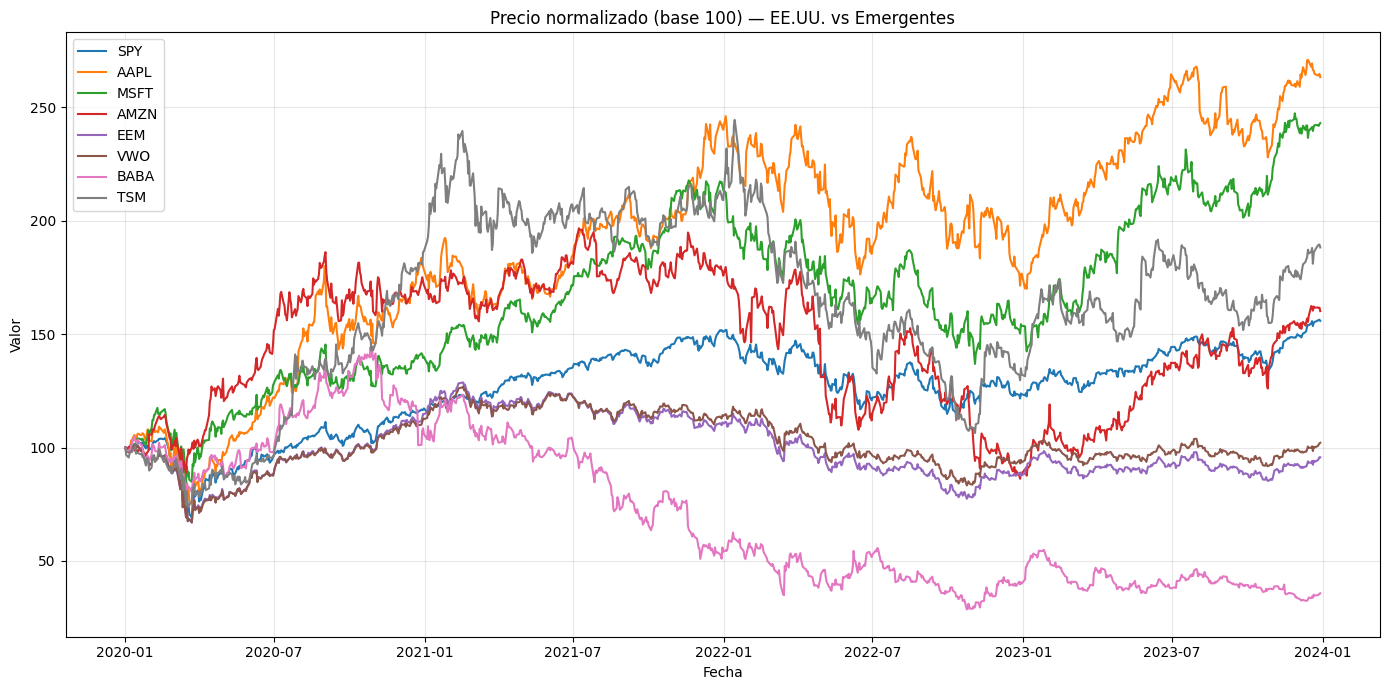

In [3]:
plt.figure(figsize=(14, 7))
for ticker in tickers_ampliado:
    normalized = (prices_ampliado[ticker] / prices_ampliado[ticker].iloc[0]) * 100
    plt.plot(normalized, label=ticker)

plt.title("Precio normalizado (base 100) — EE.UU. vs Emergentes")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../output/precios_usa_vs_emergentes.png", dpi=150)
plt.show()

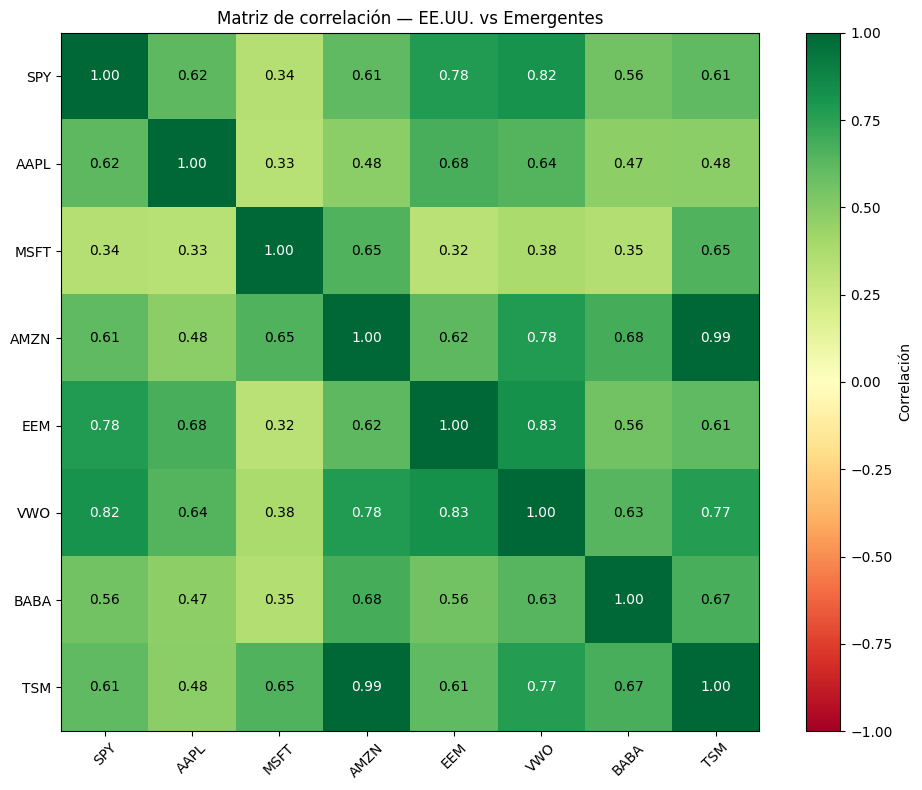

In [4]:
returns_ampliado = prices_ampliado.pct_change().dropna()
correlation_ampliado = returns_ampliado.corr()

# Mapa de calor para visualizar mejor
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(correlation_ampliado, cmap="RdYlGn", vmin=-1, vmax=1)

# Etiquetas
ax.set_xticks(range(len(tickers_ampliado)))
ax.set_yticks(range(len(tickers_ampliado)))
ax.set_xticklabels(tickers_ampliado, rotation=45)
ax.set_yticklabels(tickers_ampliado)

# Números dentro de cada celda
for i in range(len(tickers_ampliado)):
    for j in range(len(tickers_ampliado)):
        ax.text(j, i, f"{correlation_ampliado.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=10,
                color="white" if abs(correlation_ampliado.iloc[i, j]) > 0.7 else "black")

plt.colorbar(im, label="Correlación")
plt.title("Matriz de correlación — EE.UU. vs Emergentes")
plt.tight_layout()
plt.savefig("../output/correlacion_heatmap.png", dpi=150)
plt.show()

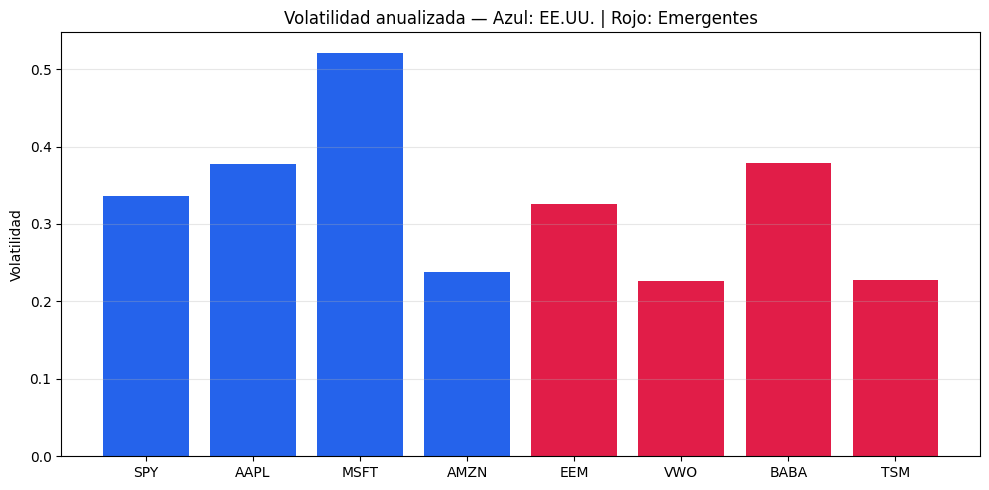

In [5]:
vol_ampliado = returns_ampliado.std() * (252 ** 0.5)

plt.figure(figsize=(10, 5))
colors = ["#2563eb" if t in ["SPY","AAPL","MSFT","AMZN"] else "#e11d48" for t in tickers_ampliado]
plt.bar(tickers_ampliado, vol_ampliado.values, color=colors)
plt.title("Volatilidad anualizada — Azul: EE.UU. | Rojo: Emergentes")
plt.ylabel("Volatilidad")
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("../output/volatilidad_comparada.png", dpi=150)
plt.show()